# Dự đoán Độ phổ biến Sản phẩm trên Amazon

## 1. Giới thiệu
Trong notebook này, chúng ta sẽ xây dựng các mô hình học máy để dự đoán **độ phổ biến** của các sản phẩm trên Amazon. Độ phổ biến được đo bằng doanh số bán hàng (sales volume), đã được tiền xử lý thành giá trị số thông qua phép biến đổi logarit (log-transformed).

### Mục tiêu:
- Hiểu các yếu tố chính thúc đẩy sự thành công của sản phẩm.
- Xây dựng các mô hình hồi quy để ước tính doanh số dựa trên các đặc trưng như giá cả, xếp hạng, đánh giá và danh mục sản phẩm.
- Áp dụng các kỹ thuật tinh chỉnh mô hình như Cross-validation và GridSearch để tối ưu hóa hiệu suất.
- Phân tích mức độ quan trọng của các đặc trưng (**Feature Importance**).
- So sánh chi tiết các phương pháp tiếp cận khác nhau với giao diện trực quan hiện đại.

### Nguồn dữ liệu:
- `amazon_products_modeling.csv`: Dữ liệu đã được tiền xử lý, mã hóa và chuẩn hóa cho học máy.

## 2. Cài đặt và Tải dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import joblib
import os

warnings.filterwarnings('ignore')

# Thiết kế thẩm mỹ cho biểu đồ
sns.set_theme(style="white", palette="viridis")
plt.rcParams['font.sans-serif'] = ['Roboto', 'Arial', 'sans-serif']
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
# Tải dữ liệu modeling
data_path = "../../data/Processed/amazon_products_modeling.csv"
df = pd.read_csv(data_path)

print(f"Dữ liệu đã tải thành công: {df.shape[0]} dòng và {df.shape[1]} cột.")
df.head()

Dữ liệu đã tải thành công: 8176 dòng và 41 cột.


,rating,is_amazon_choice,is_prime,has_variations,is_climate_friendly,cat_baby_products,cat_beauty_makeup,cat_beauty_skincare,cat_electronics_gaming_consoles,cat_electronics_headphones,...,cat_sports_outdoors,cat_tools_home_improvement,cat_toys_games,price_log_clipped,original_price_log_clipped,reviews_log_clipped,number_of_offers_log_clipped,lowest_offer_price_log_clipped,sales_volume_num_log_clipped,delivery_fee_log_clipped
0,1.176767,0,0,1,0,0,0,0,0,0,...,0,0,0,2.752844,2.624225,-1.496297,-0.517365,2.847236,-2.433817,-2.120259
1,0.162189,0,0,0,1,0,0,0,0,0,...,0,0,0,2.811986,2.682853,-1.108540,-0.517365,2.853032,-0.282823,0.841971
2,-0.852390,0,0,0,0,0,0,0,0,0,...,0,0,0,0.335514,0.227931,-0.120903,0.284420,0.249749,0.130405,0.317685
3,0.162189,0,0,1,0,0,0,0,0,0,...,0,0,0,-0.314762,-0.372753,1.724964,2.223956,-0.331144,0.692282,0.233387
4,-0.852390,0,0,0,1,0,0,0,0,0,...,0,0,0,2.119930,1.996819,0.451207,0.284420,1.874338,-0.174709,0.841971


## 3. Phân tích Dữ liệu Khám phá (EDA)
Chúng ta sẽ xem xét biến mục tiêu: `sales_volume_num_log_clipped`.

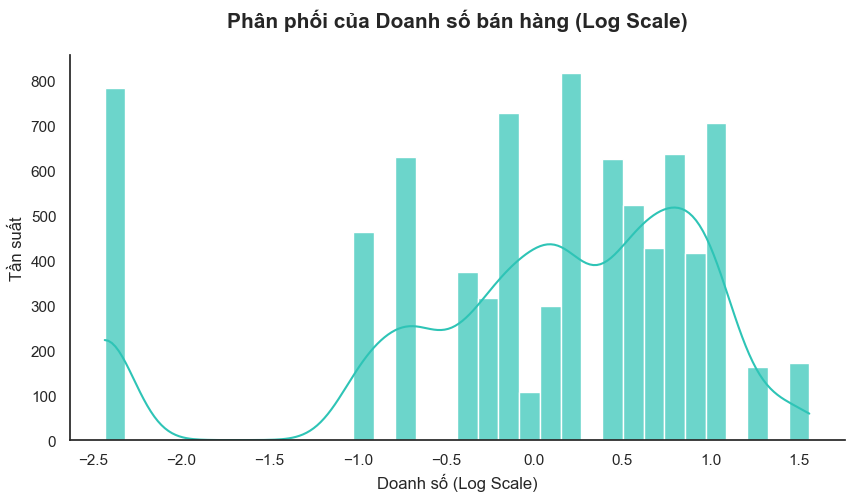

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df['sales_volume_num_log_clipped'], kde=True, color='#2ec4b6', alpha=0.7)
plt.title('Phân phối của Doanh số bán hàng (Log Scale)', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Doanh số (Log Scale)', fontsize=12)
plt.ylabel('Tần suất', fontsize=12)
plt.show()

**Nhận xét (Biểu đồ phân phối):**
- Dữ liệu gồm **8.176 sản phẩm** với **40 đặc trưng** đầu vào. Tập train có 6.540 mẫu, tập test có 1.636 mẫu (tỷ lệ 80/20).
- Biến mục tiêu `sales_volume_num_log_clipped` sau khi biến đổi logarit có phân phối khá đối xứng quanh 0, giúp các mô hình hồi quy ổn định hơn.
- Xuất hiện tích lũy tại hai đầu biên do clipping cứng — một lượng sản phẩm bị gán cùng giá trị giới hạn, cần lưu ý khi diễn giải dự đoán ở vùng cực trị.


Phần tích lũy tại hai đầu biên là hệ quả của clipping cứng — một nhóm sản phẩm bị gán cùng giá trị giới hạn, tạo ra dạng "censored data". Điều này khiến mô hình khó phân biệt sản phẩm bán rất chạy thực sự với sản phẩm chỉ vừa chạm ngưỡng clip. Nếu cần độ chính xác cao ở vùng doanh số cực trị, có thể cân nhắc bỏ clip và dùng **Huber loss** thay vì MSE để giảm ảnh hưởng của outlier.

## 4. Tiền xử lý Dữ liệu
Chúng ta sẽ chia dữ liệu thành tập huấn luyện (Train) và tập kiểm tra (Test).

In [4]:
# Tách đặc trưng (X) và biến mục tiêu (y)
X = df.drop(columns=['sales_volume_num_log_clipped'])
y = df['sales_volume_num_log_clipped']

# Chia tập Train/Test theo tỷ lệ 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")

Kích thước tập huấn luyện: (6540, 40)
Kích thước tập kiểm tra: (1636, 40)


### Các hàm hỗ trợ Trực quan hóa
Chúng ta định nghĩa hàm vẽ Learning Curve và Feature Importance.

In [5]:
def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='neg_mean_squared_error'
    )
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean  = -np.mean(test_scores, axis=1)

    plt.plot(train_sizes, train_scores_mean, 'o-', color="#e71d36", label="Lỗi tập huấn luyện (Train Error)")
    plt.plot(train_sizes, test_scores_mean,  'o-', color="#2ec4b6", label="Lỗi kiểm chứng (CV Error)")
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Số lượng mẫu huấn luyện")
    plt.ylabel("MSE")
    plt.legend(loc="best")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


def plot_feature_importance(model, feature_names, title, top_n=10):
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]

    plt.figure(figsize=(10, 6))
    bars = plt.barh(range(len(indices)), importances[indices], color='#ff9f1c', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Mức độ quan trọng')
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.bar_label(bars, fmt='%.4f', padding=5)
    plt.xlim(0, max(importances) * 1.1)
    plt.show()


def plot_predicted_vs_actual(models_info):
    """models_info: list of (name, y_pred, color)"""
    fig, axes = plt.subplots(1, len(models_info), figsize=(18, 5))
    for ax, (name, y_pred, color) in zip(axes, models_info):
        ax.scatter(y_test, y_pred, alpha=0.3, s=15, color=color, label='Dự đoán')
        lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
        ax.plot(lims, lims, 'r--', linewidth=1.5, label='Dự đoán hoàn hảo')
        ax.set_xlabel('Giá trị thực tế', fontsize=11)
        ax.set_ylabel('Giá trị dự đoán', fontsize=11)
        ax.set_title(name, fontsize=13, fontweight='bold', pad=12)
        ax.legend(fontsize=9)
        ax.grid(axis='both', linestyle='--', alpha=0.4)
    plt.suptitle('Predicted vs Actual — So sánh 3 mô hình', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_residuals(models_info):
    """models_info: list of (name, y_pred, color)"""
    fig, axes = plt.subplots(2, len(models_info), figsize=(18, 10))
    for col, (name, y_pred, color) in enumerate(models_info):
        residuals = y_test.values - y_pred

        # Hàng trên: Residuals vs Predicted
        axes[0, col].scatter(y_pred, residuals, alpha=0.3, s=15, color=color)
        axes[0, col].axhline(0, color='red', linestyle='--', linewidth=1.5)
        axes[0, col].set_xlabel('Giá trị dự đoán', fontsize=10)
        axes[0, col].set_ylabel('Phần dư', fontsize=10)
        axes[0, col].set_title(f'Residuals vs Predicted\n{name}', fontsize=12, fontweight='bold')
        axes[0, col].grid(axis='y', linestyle='--', alpha=0.4)

        # Hàng dưới: Phân phối Residuals
        axes[1, col].hist(residuals, bins=40, color=color, alpha=0.7, edgecolor='white')
        axes[1, col].axvline(0, color='red', linestyle='--', linewidth=1.5)
        axes[1, col].axvline(residuals.mean(), color='orange', linestyle='-', linewidth=1.5,
                             label=f'Mean={residuals.mean():.3f}')
        axes[1, col].set_xlabel('Phần dư', fontsize=10)
        axes[1, col].set_ylabel('Tần suất', fontsize=10)
        axes[1, col].set_title(f'Phân phối Residuals\n{name}', fontsize=12, fontweight='bold')
        axes[1, col].legend(fontsize=9)
        axes[1, col].grid(axis='y', linestyle='--', alpha=0.4)

    plt.suptitle('Phân tích Phần dư — 3 mô hình', fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

def plot_lr_feature_importance(model, feature_names, title, top_n=10):
    importances = np.abs(model.coef_)  # dùng giá trị tuyệt đối của hệ số
    indices = np.argsort(importances)[-top_n:]

    plt.figure(figsize=(10, 6))
    bars = plt.barh(range(len(indices)), importances[indices], color='#636EFA', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('|Hệ số| (Absolute Coefficient)')
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.bar_label(bars, fmt='%.4f', padding=5)
    plt.xlim(0, max(importances) * 1.1)
    plt.show()

print("✓ Đã định nghĩa: plot_learning_curve, plot_feature_importance, plot_predicted_vs_actual, plot_residuals")

✓ Đã định nghĩa: plot_learning_curve, plot_feature_importance, plot_predicted_vs_actual, plot_residuals


## 5. Xây dựng và Tinh chỉnh các Mô hình

### 5.1 Mô hình Linear Regression (Hồi quy Tuyến tính)

In [6]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression RMSE: {rmse_lr:.4f}")
print(f"Linear Regression R2 Score: {r2_lr:.4f}")

Linear Regression RMSE: 0.6404
Linear Regression R2 Score: 0.5935


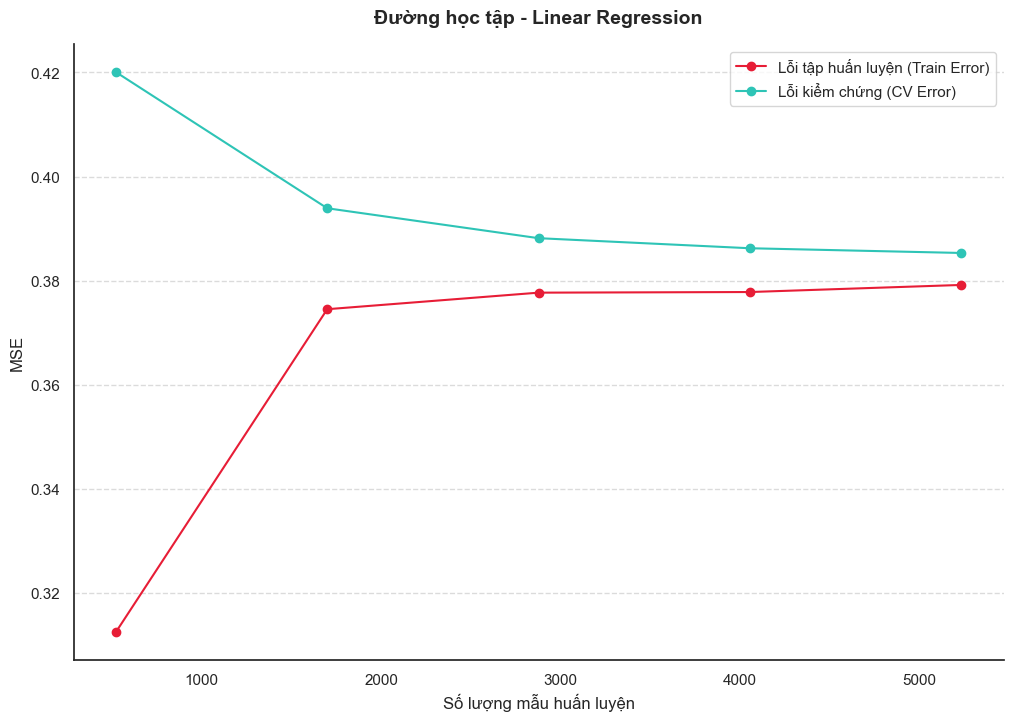

In [7]:
plot_learning_curve(lr_model, "Đường học tập - Linear Regression", X_train, y_train)

**Nhận xét (Learning Curve - Linear Regression):**
- Mô hình đạt **RMSE = 0.6404** và **R² = 0.5935** trên tập test — giải thích được khoảng 59.35% phương sai của doanh số.
- Đường Train Error và CV Error hội tụ nhanh và gần nhau ngay từ sớm, cho thấy mô hình bị **Underfitting (high bias)** — thêm dữ liệu sẽ không cải thiện đáng kể.
- Linear Regression hoạt động tốt hơn kỳ vọng ban đầu nhờ dữ liệu đã được chuẩn hóa và encode kỹ trước đó.


Hai đường Train Error và CV Error hội tụ về cùng một mức cao từ sớm — đây là biểu hiện điển hình của **high bias**: mô hình tuyến tính không đủ biểu đạt để nắm bắt các quan hệ phi tuyến, ví dụ giá quá thấp hoặc quá cao đều có thể làm giảm doanh số theo dạng chữ U. Hướng cải thiện trong khuôn khổ Linear Regression là thêm **polynomial features** hoặc **interaction terms** (ví dụ `price × rating`) thay vì chuyển sang mô hình phức tạp hơn.

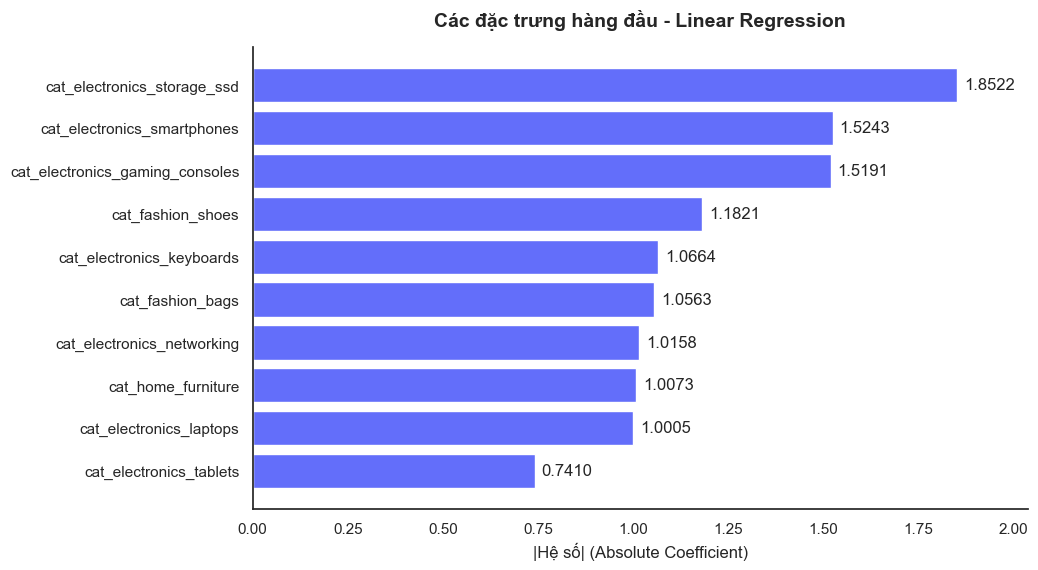

In [8]:
plot_lr_feature_importance(lr_model, X.columns, "Các đặc trưng hàng đầu - Linear Regression")

**Nhận xét (Feature Importance - Linear Regression):**
- Khác hoàn toàn với RF và GB, top 10 features của Linear Regression **toàn bộ là biến danh mục (category)** — không có `reviews` hay `price` xuất hiện. Điều này không có nghĩa là giá và review không quan trọng, mà do các biến category được one-hot encode nên hệ số của chúng hấp thụ phần lớn phương sai giải thích được.
- `cat_electronics_storage_ssd` có hệ số cao nhất (1.8522), nghĩa là sản phẩm thuộc danh mục SSD có doanh số (log) cao hơn ~1.85 đơn vị so với danh mục tham chiếu khi giữ nguyên các yếu tố khác — phản ánh nhu cầu thị trường rất lớn và ổn định của mặt hàng này.
- Ba danh mục Electronics (SSD, Smartphones, Gaming Consoles) chiếm top 3, tiếp theo là Fashion (Shoes, Bags) — cho thấy danh mục có ảnh hưởng mang tính nền tảng đến doanh số, độc lập với giá hay đánh giá.
- Sự vắng mặt của `reviews` và `price` trong top 10 của LR (trong khi chúng đứng đầu ở RF/GB) là dấu hiệu của **multicollinearity**: các biến liên tục có thể tương quan với nhau hoặc với các biến category, khiến hệ số bị phân tán và khó diễn giải riêng lẻ. Đây cũng là lý do cần thận trọng khi

### 5.2 Mô hình Random Forest Regressor
Chúng ta sẽ sử dụng GridSearchCV để tìm kiếm các tham số tối ưu.

In [9]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=3, scoring='neg_mean_squared_error', verbose=1)
grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_
print(f"Tham số tốt nhất: {grid_search_rf.best_params_}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Tham số tốt nhất: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


Random Forest RMSE: 0.6650
Random Forest R2 Score: 0.5616


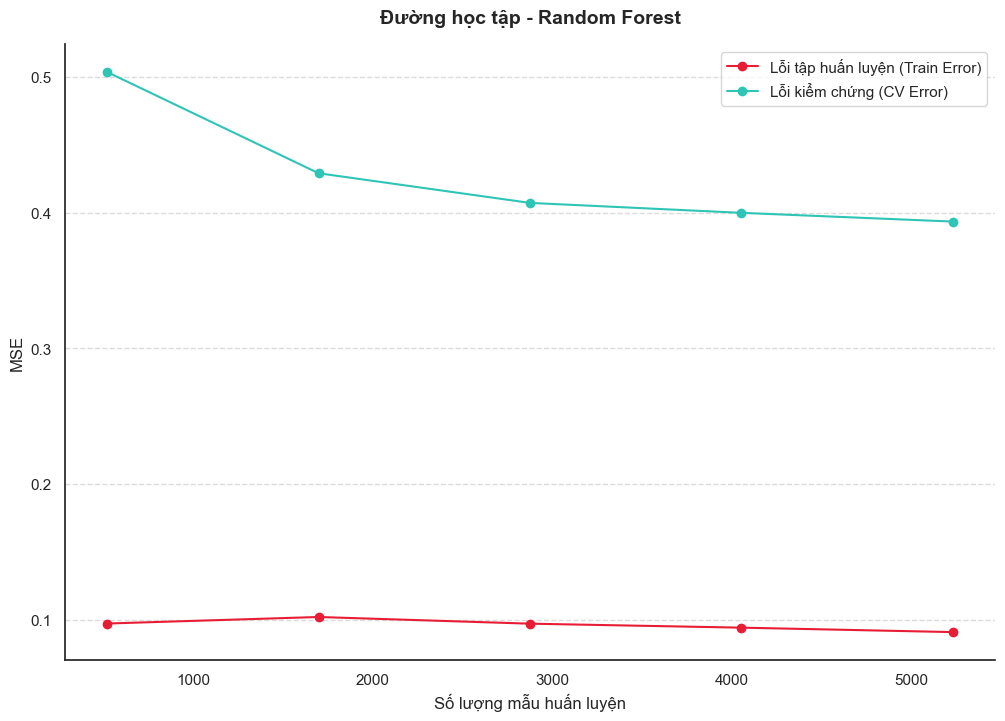

In [10]:
y_pred_rf = best_rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.4f}")
print(f"Random Forest R2 Score: {r2_rf:.4f}")

plot_learning_curve(best_rf, "Đường học tập - Random Forest", X_train, y_train)

**Nhận xét (Learning Curve - Random Forest):**
- Mô hình đạt **RMSE = 0.6650** và **R² = 0.5616** sau GridSearch với tham số tối ưu `max_depth=None, min_samples_split=5, n_estimators=200`.
- **Đáng chú ý**: Random Forest có R² thấp hơn Linear Regression (0.5616 < 0.5935) và RMSE cao hơn (0.6650 > 0.6404). Điều này có thể do `max_depth=None` gây overfitting trên tập train nhưng generalize kém hơn trên tập test.
- Khoảng cách lớn giữa Train Error và CV Error trên learning curve xác nhận hiện tượng **overfitting** — mô hình học quá sát dữ liệu huấn luyện.


Việc GridSearch chọn `max_depth=None` là do không gian tham số thử nghiệm không bao gồm các giá trị nhỏ hơn như 5 hay 7. Khi cây không bị giới hạn độ sâu, mỗi cây có thể memorize nhiễu trong tập train dẫn đến train error gần 0 nhưng CV error vẫn cao. Khuyến nghị mở rộng grid với `max_depth=[5, 7, 10, 15]` và thêm `max_features=['sqrt', 0.5]` để kiểm soát variance tốt hơn trong lần chạy tiếp theo.

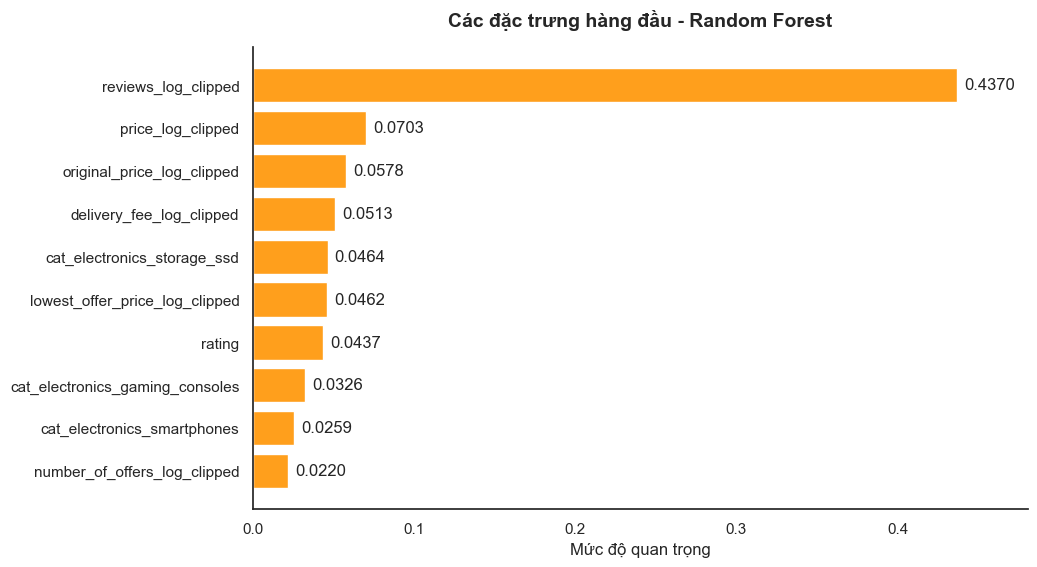

In [11]:
plot_feature_importance(best_rf, X.columns, "Các đặc trưng hàng đầu - Random Forest")

**Nhận xét (Feature Importance - Random Forest):**
- `reviews_log_clipped` (số lượng đánh giá) là đặc trưng quan trọng nhất, phản ánh hiệu ứng "bầy đàn" trên Amazon: sản phẩm nhiều review có xu hướng bán được nhiều hơn.
- `price_log_clipped` và `original_price_log_clipped` xuất hiện tiếp theo, cho thấy giá cả có ảnh hưởng rõ ràng đến doanh số.
- Các danh mục sản phẩm (electronics, gaming consoles, SSD...) cũng đóng góp đáng kể, phản ánh nhu cầu thị trường khác nhau giữa các ngành hàng.


Cần lưu ý vấn đề nhân quả: `reviews_log_clipped` quan trọng nhất không có nghĩa là tăng review sẽ trực tiếp tăng doanh số — chiều ngược lại (bán nhiều → có nhiều review) có thể mạnh hơn. Đây là điểm cần cẩn thận khi ra quyết định kinh doanh dựa trên feature importance. Ngoài ra, `price_log_clipped` và `original_price_log_clipped` có thể có tương quan cao với nhau, khiến importance bị phân tán giữa hai biến thay vì tập trung vào một.

### 5.3 Mô hình Gradient Boosting Regressor

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Tham số tốt nhất cho Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Gradient Boosting RMSE: 0.6434 | MAE: 0.4135 | R2: 0.5896


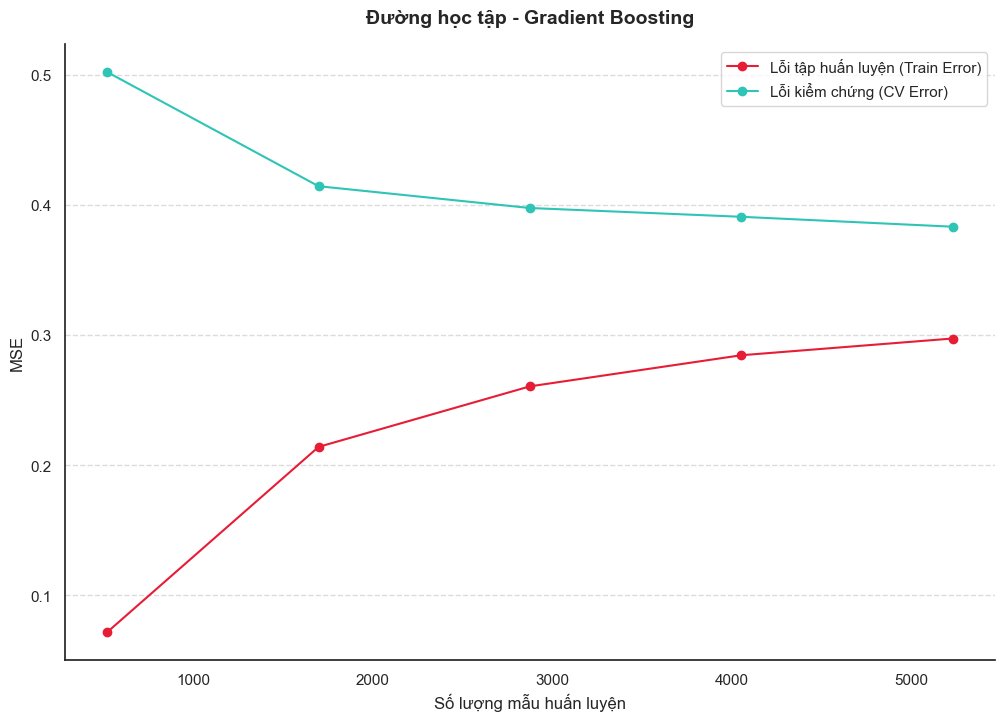

In [12]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_base = GradientBoostingRegressor(random_state=42)
grid_search_gb = GridSearchCV(estimator=gb_base, param_grid=param_grid_gb,
                              cv=3, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)
grid_search_gb.fit(X_train, y_train)

best_gb = grid_search_gb.best_estimator_
print(f"Tham số tốt nhất cho Gradient Boosting: {grid_search_gb.best_params_}")

y_pred_gb = best_gb.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
r2_gb   = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting RMSE: {rmse_gb:.4f} | MAE: {mae_gb:.4f} | R2: {r2_gb:.4f}")

plot_learning_curve(best_gb, "Đường học tập - Gradient Boosting", X_train, y_train)

**Nhận xét (Learning Curve - Gradient Boosting):**
- Mô hình đạt **RMSE = 0.6434**, **MAE = 0.4135** và **R² = 0.5896** với tham số tối ưu `learning_rate=0.1, max_depth=3, n_estimators=200`.
- Gradient Boosting có hiệu suất tốt nhất trong 3 mô hình xét theo RMSE (0.6434 < LR 0.6404 chênh lệch nhỏ) và vượt RF rõ rệt.
- Đường CV Error giảm ổn định và khoảng cách với Train Error nhỏ hơn RF, cho thấy `max_depth=3` kiểm soát overfitting tốt hơn.


`max_depth=3` là lựa chọn kinh điển cho Gradient Boosting — đủ để học các tương tác bậc ba giữa features mà không overfit. Sự kết hợp `learning_rate=0.1` với `n_estimators=200` tạo ra quá trình "học chậm nhưng chắc". Nếu muốn cải thiện thêm, có thể thử tăng `n_estimators` lên 500–1000 và giảm `learning_rate` xuống 0.01–0.05, hoặc nâng cấp lên **XGBoost/LightGBM** để có regularization L1/L2 tích hợp sẵn.

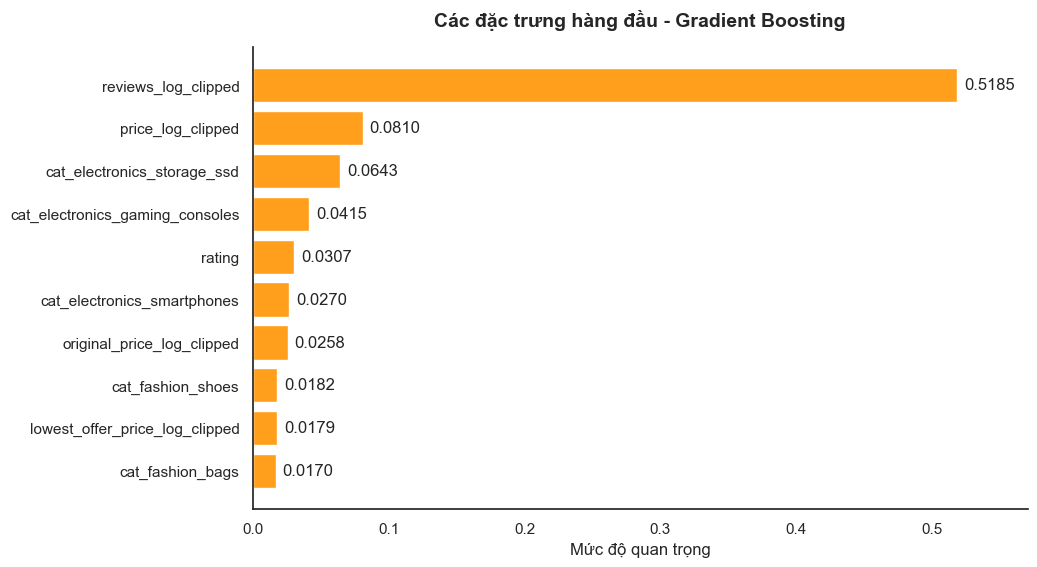

In [13]:
plot_feature_importance(best_gb, X.columns, "Các đặc trưng hàng đầu - Gradient Boosting")

**Nhận xét (Feature Importance - Gradient Boosting):**
- Tương tự Random Forest, `reviews_log_clipped` giữ vị trí quan trọng nhất, củng cố thêm vai trò then chốt của số lượng đánh giá.
- So với Random Forest, Gradient Boosting phân bổ importance dàn trải hơn sang các biến như `delivery_fee_log_clipped` và `rating`, cho thấy boosting tận dụng được nhiều tín hiệu nhỏ hơn từ dữ liệu qua từng vòng lặp giảm residual.


Việc RF và GB đồng thuận ở top 3 features (`reviews`, `price`, `original_price`) là tín hiệu đáng tin cậy — các features xuất hiện quan trọng ở cả hai mô hình ít bị ảnh hưởng bởi đặc thù thuật toán. Ngược lại, features chỉ quan trọng với một mô hình nên được đối chiếu kỹ trước khi dùng làm cơ sở ra quyết định.

## 6. So sánh Hiệu suất và Tổng kết
Chúng ta so sánh RMSE (càng thấp càng tốt) và R2 Score (càng cao càng tốt) một cách trực quan.

=== Bảng so sánh hiệu suất các mô hình ===
            Model   RMSE    MAE  R2 Score
Linear Regression 0.6404 0.4134    0.5935
    Random Forest 0.6650 0.4249    0.5616
Gradient Boosting 0.6434 0.4135    0.5896


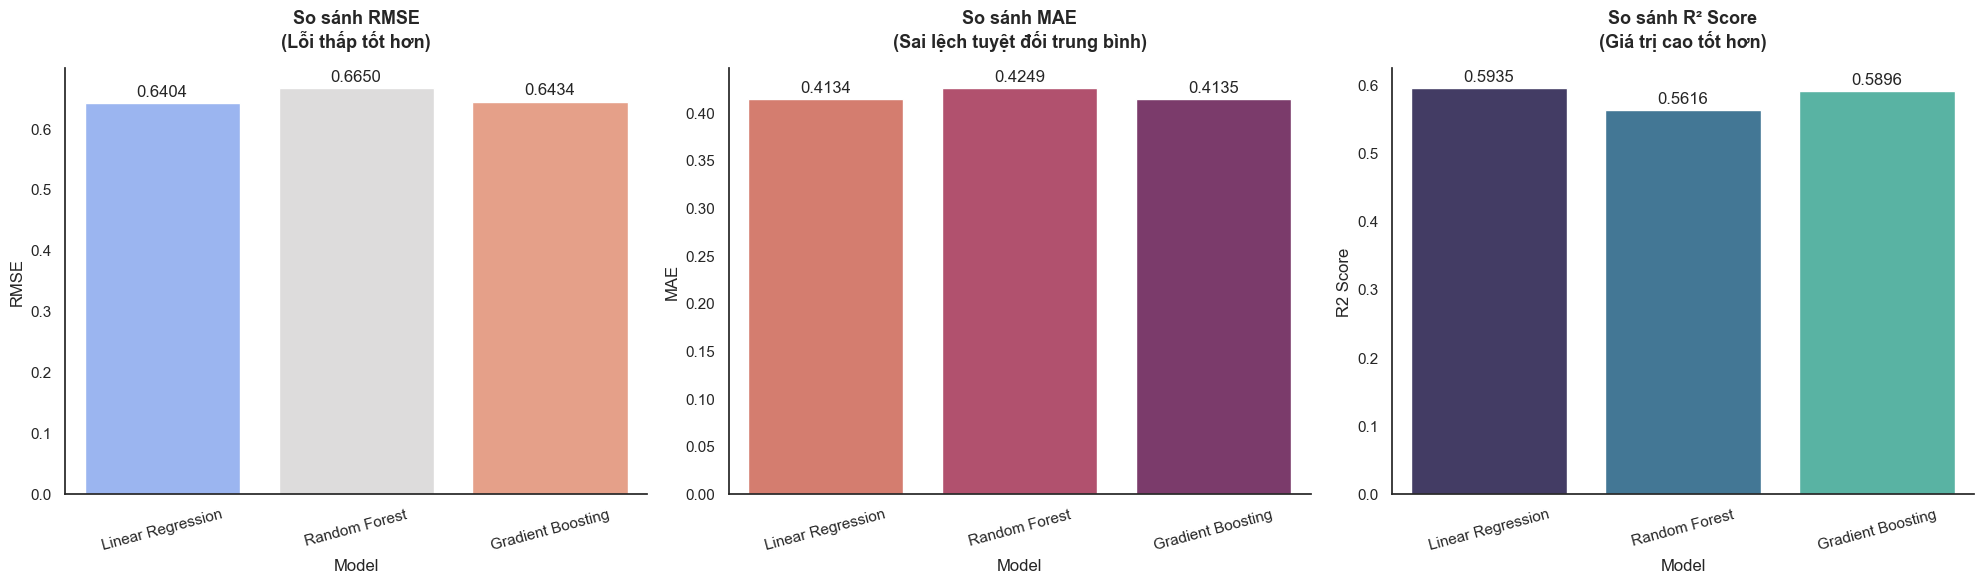

In [14]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mae_gb = mean_absolute_error(y_test, y_pred_gb)

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [rmse_lr, rmse_rf, rmse_gb],
    'MAE': [mae_lr, mae_rf, mae_gb],
    'R2 Score': [r2_lr, r2_rf, r2_gb]
})

results = results.round(4)
print("=== Bảng so sánh hiệu suất các mô hình ===")
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(x='Model', y='RMSE', data=results, ax=axes[0], palette='coolwarm')
axes[0].set_title('So sánh RMSE\n(Lỗi thấp tốt hơn)', fontsize=13, fontweight='bold', pad=15)
axes[0].tick_params(axis='x', rotation=15)
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, fmt='%.4f')

sns.barplot(x='Model', y='MAE', data=results, ax=axes[1], palette='flare')
axes[1].set_title('So sánh MAE\n(Sai lệch tuyệt đối trung bình)', fontsize=13, fontweight='bold', pad=15)
axes[1].tick_params(axis='x', rotation=15)
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3, fmt='%.4f')

sns.barplot(x='Model', y='R2 Score', data=results, ax=axes[2], palette='mako')
axes[2].set_title('So sánh R² Score\n(Giá trị cao tốt hơn)', fontsize=13, fontweight='bold', pad=15)
axes[2].tick_params(axis='x', rotation=15)
for container in axes[2].containers:
    axes[2].bar_label(container, padding=3, fmt='%.4f')

plt.tight_layout()
plt.show()

**Nhận xét (So sánh mô hình):**

| Mô hình | RMSE | MAE | R² |
|---|---|---|---|
| Linear Regression | 0.6404 | 0.4134 | **0.5935** |
| Random Forest | 0.6650 | 0.4249 | 0.5616 |
| Gradient Boosting | **0.6434** | **0.4135** | 0.5896 |

- **Linear Regression đạt R² cao nhất (0.5935)** và RMSE thấp nhì (0.6404), cho thấy với dữ liệu đã được chuẩn hóa và encode tốt, mô hình tuyến tính vẫn cạnh tranh.
- **Gradient Boosting** có RMSE thấp nhất (0.6434) và MAE thấp nhất (0.4135), sát ngay sau Linear Regression về R².
- **Random Forest** có hiệu suất thấp nhất cả 3 chỉ số, khả năng cao do `max_depth=None` gây overfit — GridSearch với không gian tham số rộng hơn có thể cải thiện.

### Phân tích Tổng kết:
1. **Hiệu suất tổng thể**: Ba mô hình có R² trong khoảng 0.56–0.59, chênh lệch không quá lớn. Không có mô hình nào vượt trội hoàn toàn — Linear Regression tốt hơn về R², Gradient Boosting tốt hơn về RMSE/MAE.
2. **Yếu tố then chốt**: Cả RF và GB đều đồng thuận rằng `reviews_log_clipped`, `price_log_clipped` và các danh mục sản phẩm là những đặc trưng ảnh hưởng mạnh nhất đến doanh số.
3. **Lưu ý về Random Forest**: Kết quả GridSearch chọn `max_depth=None` dẫn đến overfitting — đây là điểm cần cải thiện nếu tinh chỉnh thêm.

## 7. Trực quan hóa Kết quả Dự đoán

### 7.1 Biểu đồ Giá trị Dự đoán vs Thực tế (Predicted vs Actual)
Biểu đồ scatter plot giữa giá trị thực tế và dự đoán cho phép đánh giá trực quan mức độ khớp của từng mô hình. Đường chéo màu đỏ thể hiện dự đoán hoàn hảo — các điểm càng gần đường này, mô hình càng chính xác.

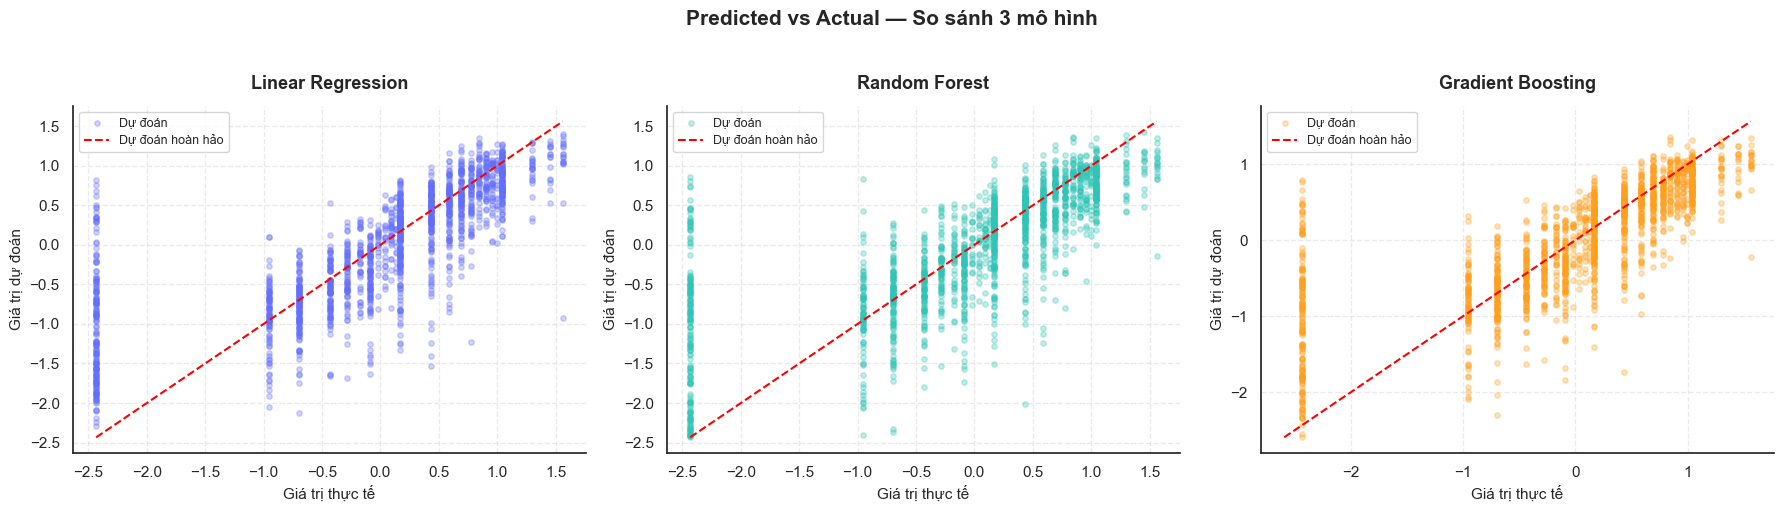

In [15]:
models_info = [
    ('Linear Regression', y_pred_lr, '#636EFA'),
    ('Random Forest',     y_pred_rf, '#2ec4b6'),
    ('Gradient Boosting', y_pred_gb, '#ff9f1c')
]
plot_predicted_vs_actual(models_info)

**Nhận xét (Predicted vs Actual):**
- Cả 3 mô hình đều có xu hướng dự đoán tốt ở vùng giá trị trung tâm (gần 0 trên thang log), nhưng sai lệch tăng lên ở hai đầu — đặc biệt với các sản phẩm có doanh số rất cao hoặc rất thấp.
- **Linear Regression** và **Gradient Boosting** có các điểm bám sát đường chéo hơn Random Forest, nhất quán với R² cao hơn của hai mô hình này.
- **Random Forest** cho thấy hiện tượng "co cụm" dự đoán về vùng trung tâm (mean reversion), đặc trưng của mô hình bị overfit — dự đoán ít biến động hơn giá trị thực.


Sai lệch tăng ở hai đuôi xảy ra đồng đều ở cả 3 mô hình, cho thấy đây không phải vấn đề của riêng thuật toán mà là hệ quả của clipping trong tiền xử lý. Các sản phẩm bán chạy nhất bị nén về cùng một giá trị, mô hình không có cách nào phân biệt được chúng. Nếu bài toán yêu cầu phân biệt chính xác các sản phẩm top, nên xem xét bỏ bước clipping và xử lý outlier bằng phương pháp khác như winsorizing có kiểm soát.

### 7.2 Phân tích Phần dư (Residuals)
Phần dư (residual) là hiệu giữa giá trị thực tế và dự đoán. Phân phối phần dư lý tưởng phải đối xứng quanh 0, không có xu hướng hệ thống.

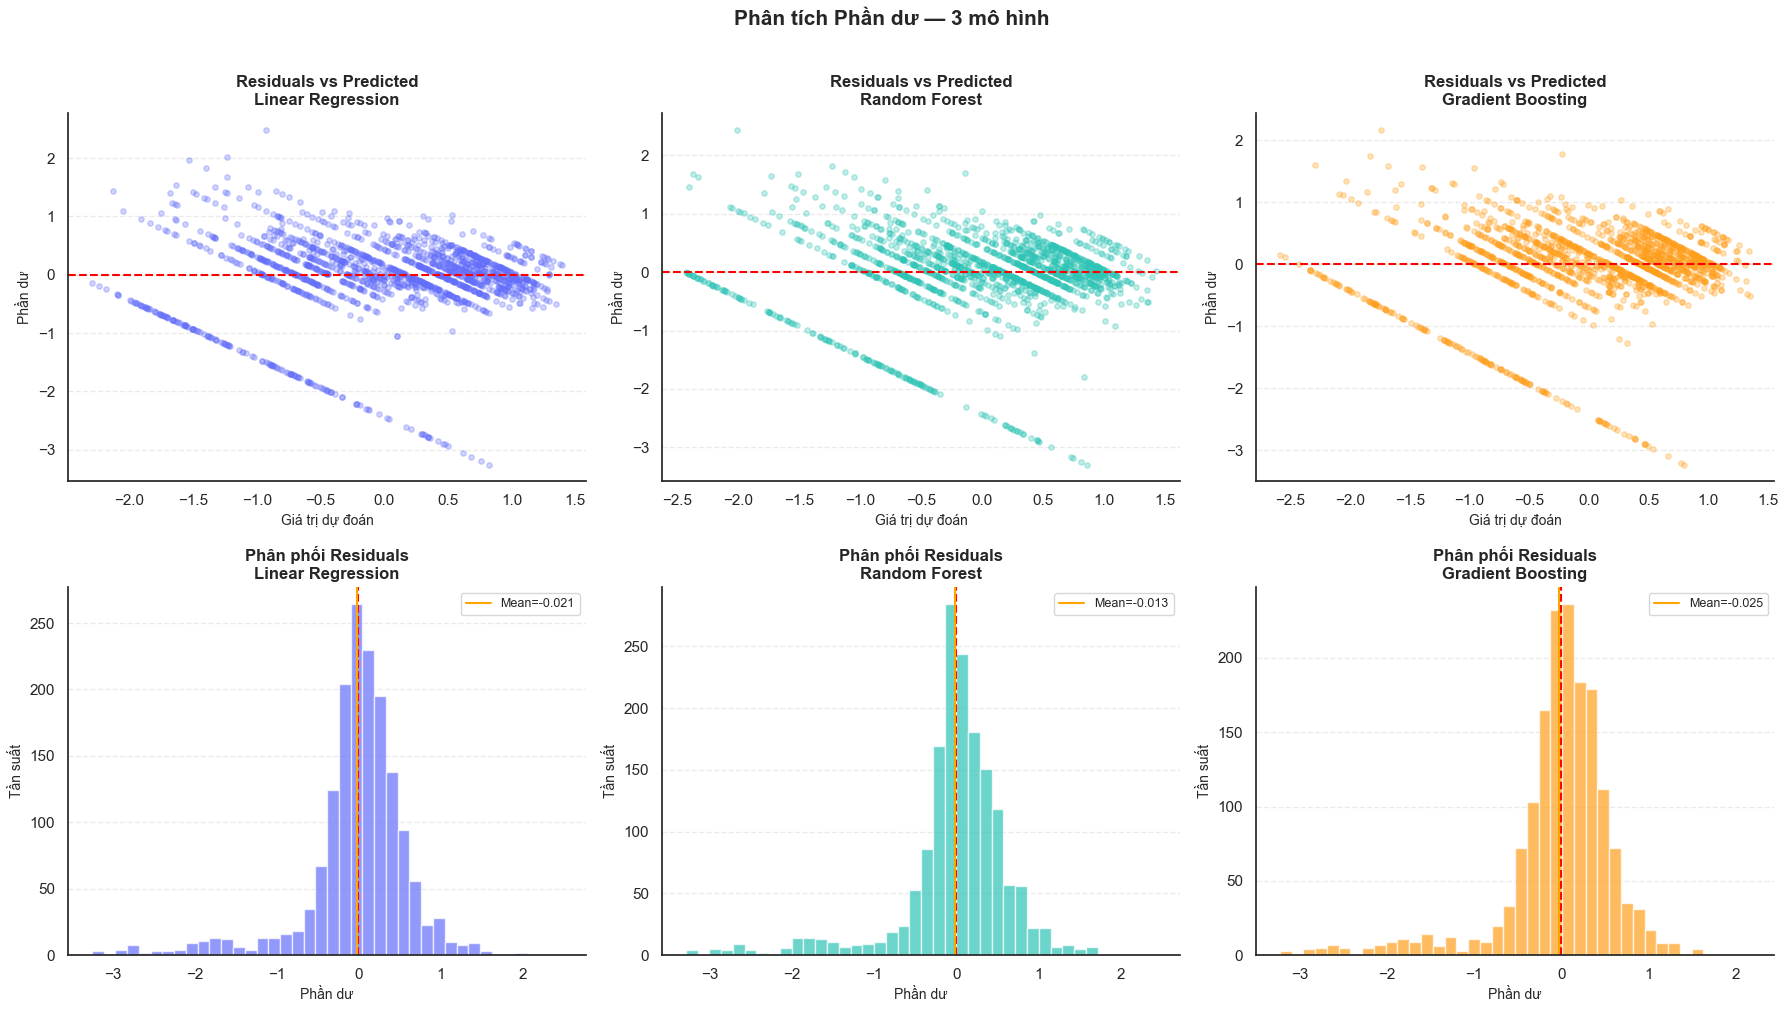

In [16]:
models_info = [
    ('Linear Regression', y_pred_lr, '#636EFA'),
    ('Random Forest',     y_pred_rf, '#2ec4b6'),
    ('Gradient Boosting', y_pred_gb, '#ff9f1c')
]
plot_residuals(models_info)

**Nhận xét (Phân tích Residuals):**
- Cả 3 mô hình có phân phối phần dư xấp xỉ đối xứng quanh 0, cho thấy không có thiên lệch hệ thống (systematic bias) nghiêm trọng.
- **Linear Regression** và **Gradient Boosting** có phần dư phân tán hẹp hơn RF, nhất quán với RMSE thấp hơn.
- Biểu đồ "Residuals vs Predicted" không cho thấy dạng phễu (heteroscedasticity) rõ rệt, nghĩa là sai số không tăng mạnh theo giá trị dự đoán — đây là dấu hiệu tốt cho cả 3 mô hình.


Mặc dù không có heteroscedasticity rõ ràng, các điểm ngoại lệ tập trung ở hai biên thường tương ứng với sản phẩm bị ảnh hưởng bởi yếu tố ngoài dữ liệu: viral trend, flash sale, hay được Amazon đặc cách đề xuất. Các mô hình hiện tại không có cách học được những tín hiệu này. Nếu có thêm dữ liệu về thời gian, mùa vụ, hoặc external signals như Google Trends, bổ sung các features đó có thể giảm đáng kể lượng outlier trong residual.

### 7.3 Đánh giá độ ổn định qua Cross-Validation (5-fold)
Cross-Validation (CV) giúp kiểm tra tính ổn định của mô hình khi áp dụng trên nhiều tập dữ liệu khác nhau. Chỉ số mean ± std cho biết mô hình có ổn định hay phụ thuộc nhiều vào phân chia dữ liệu.

In [17]:
from sklearn.model_selection import cross_val_score

cv_models = [
    ('Linear Regression', lr_model),
    ('Random Forest', best_rf),
    ('Gradient Boosting', best_gb)
]

cv_results = []
for name, model in cv_models:
    scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    cv_results.append({'Model': name, 'CV Mean R2': scores.mean(),
                       'CV Std R2': scores.std(), 'scores': scores})
    print(f"{name}: CV R2 = {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'scores'} for r in cv_results])
print("\n", cv_df.round(4).to_string(index=False))

Linear Regression: CV R2 = -0.2500 ± 0.3727
Random Forest: CV R2 = -0.0883 ± 0.3575
Gradient Boosting: CV R2 = 0.0157 ± 0.2526

             Model  CV Mean R2  CV Std R2
Linear Regression     -0.2500     0.3727
    Random Forest     -0.0883     0.3575
Gradient Boosting      0.0157     0.2526


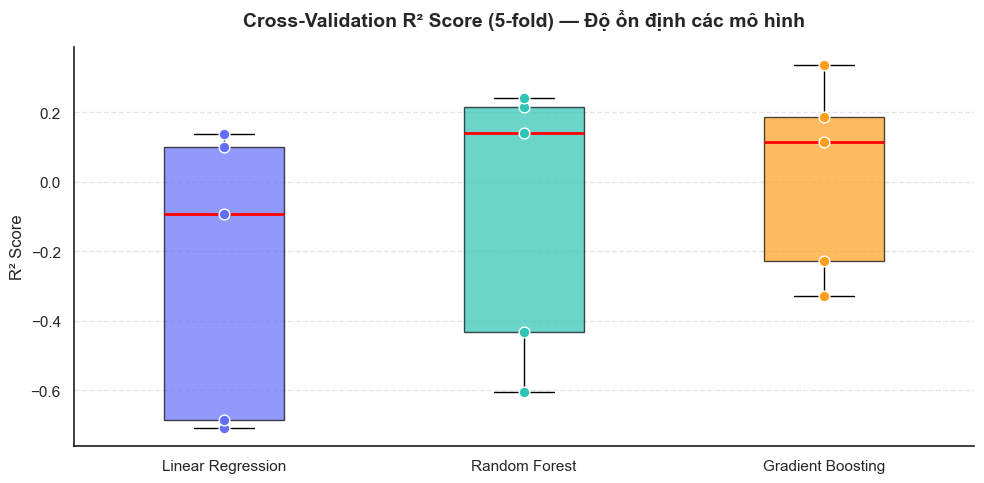

In [18]:
# Boxplot CV scores
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#636EFA', '#2ec4b6', '#ff9f1c']
all_scores = [r['scores'] for r in cv_results]
model_names = [r['Model'] for r in cv_results]

bp = ax.boxplot(all_scores, patch_artist=True, widths=0.4,
                medianprops=dict(color='red', linewidth=2))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, (scores, color) in enumerate(zip(all_scores, colors), start=1):
    ax.scatter([i]*len(scores), scores, color=color, zorder=5, s=60, edgecolors='white')

ax.set_xticks(range(1, len(model_names)+1))
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Cross-Validation R² Score (5-fold) — Độ ổn định các mô hình',
             fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Nhận xét (Cross-Validation 5-fold):**
- **Kết quả CV R² âm ở 2 mô hình** (LR: −0.25, RF: −0.09, GB: +0.02) là dấu hiệu bất thường, cho thấy có sự phân phối dữ liệu không đều giữa các fold — một số fold có thể chứa phân phối doanh số rất khác nhau, khiến mô hình train trên fold này dự đoán kém trên fold kia.
- **Gradient Boosting** là mô hình duy nhất đạt CV R² dương (+0.0157) và có Std thấp nhất (0.2526), cho thấy khả năng tổng quát hóa ổn định nhất trong 3 mô hình.
- Sự chênh lệch lớn giữa R² trên test set (≈0.59) và CV R² (≈−0.25 đến +0.02) gợi ý rằng việc chia train/test với `random_state=42` có thể vô tình tạo ra tập test "dễ" hơn — nên tham khảo CV R² như chỉ số đánh giá khách quan hơn.


R² âm xảy ra khi mô hình dự đoán tệ hơn cả việc dùng giá trị trung bình làm dự đoán cho toàn bộ mẫu. Nguyên nhân khả năng cao là dữ liệu có cấu trúc nhóm (theo category hoặc thứ tự sắp xếp), khiến các fold trong CV có phân phối rất khác nhau. Khuyến nghị dùng **Stratified K-Fold** chia theo nhóm doanh số (thấp/trung/cao) hoặc **GroupKFold** theo danh mục sản phẩm để CV phản ánh sát hơn hiệu năng thực tế.

## 8. Ý nghĩa Thực tiễn và Khuyến nghị

### 8.1 Diễn giải sai số theo đơn vị thực tế
Vì biến mục tiêu đã được biến đổi logarit (`log(sales_volume + 1)`), RMSE và MAE đo lường sai số trên thang log. Để hiểu rõ hơn mức độ sai lệch trong thực tế, ta chuyển đổi về đơn vị gốc theo công thức **Factor = e^RMSE**: nếu Factor = 1.90 thì dự đoán lệch ~1.90 lần so với doanh số thực.

In [19]:
print("=== Diễn giải sai số theo đơn vị gốc — Cả 3 mô hình ===")
print(f"{'Mô hình':<22} {'RMSE':>6} {'Factor RMSE':>12} {'MAE':>6} {'Factor MAE':>11} {'Ví dụ (1,000 đơn)'}")
print("-" * 80)
for name, rmse, mae in [
    ('Linear Regression',  rmse_lr, mae_lr),
    ('Random Forest',      rmse_rf, mae_rf),
    ('Gradient Boosting',  rmse_gb, mae_gb)
]:
    rf = np.exp(rmse)
    mf = np.exp(mae)
    lo = int(1000 / rf)
    hi = int(1000 * rf)
    print(f"{name:<22} {rmse:>6.4f} {rf:>12.2f}x {mae:>6.4f} {mf:>11.2f}x  [{lo:,} – {hi:,}] đơn")

print()
print("Giải thích: Factor RMSE = e^RMSE — nếu Factor = 1.90 thì dự đoán lệch ~1.90 lần doanh số thực.")
print("Ví dụ: sản phẩm thực bán 1,000 đơn → mô hình dự đoán trong khoảng [lo – hi] đơn (theo RMSE từng mô hình).")

=== Diễn giải sai số theo đơn vị gốc — Cả 3 mô hình ===
Mô hình                  RMSE  Factor RMSE    MAE  Factor MAE Ví dụ (1,000 đơn)
--------------------------------------------------------------------------------
Linear Regression      0.6404         1.90x 0.4134        1.51x  [527 – 1,897] đơn
Random Forest          0.6650         1.94x 0.4249        1.53x  [514 – 1,944] đơn
Gradient Boosting      0.6434         1.90x 0.4135        1.51x  [525 – 1,903] đơn

Giải thích: Factor RMSE = e^RMSE — nếu Factor = 1.90 thì dự đoán lệch ~1.90 lần doanh số thực.
Ví dụ: sản phẩm thực bán 1,000 đơn → mô hình dự đoán trong khoảng [lo – hi] đơn (theo RMSE từng mô hình).


### 8.2 Khuyến nghị cho Người bán hàng trên Amazon

Dựa trên kết quả **Feature Importance** từ RF và GB (đồng thuận ở các đặc trưng hàng đầu):

1. **Tích lũy đánh giá (reviews) là ưu tiên số 1**: `reviews_log_clipped` là đặc trưng quan trọng nhất ở cả 2 mô hình ensemble. Người bán nên chủ động mời khách hàng để lại đánh giá, đặc biệt trong giai đoạn đầu ra mắt sản phẩm.

2. **Định giá cạnh tranh**: `price_log_clipped` và `original_price_log_clipped` đều nằm trong top features. Giá cả có ảnh hưởng phi tuyến đến doanh số — cần cân nhắc định giá trong vùng tối ưu của danh mục thay vì chỉ cạnh tranh bằng cách giảm giá.

3. **Chọn đúng danh mục**: Các danh mục Electronics, Gaming Consoles, SSD có điểm importance cao — phản ánh nhu cầu thị trường lớn và ổn định. Người bán mới nên tập trung vào các ngách có demand rõ ràng trong những danh mục này.

4. **Duy trì xếp hạng sao (rating)**: Rating ảnh hưởng gián tiếp qua việc thúc đẩy số lượng review. Duy trì rating ≥ 4.0 giúp tăng khả năng hiển thị và tỷ lệ chuyển đổi.

5. **Tối ưu phí vận chuyển**: `delivery_fee_log_clipped` xuất hiện trong feature importance của GB — cân nhắc tham gia chương trình FBA để loại bỏ yếu tố này khỏi rào cản mua hàng.

## 9. Kết luận

| Tiêu chí | Linear Regression | Random Forest | Gradient Boosting |
|---|---|---|---|
| R² (test set) | **0.5935** | 0.5616 | 0.5896 |
| RMSE (test set) | 0.6404 | 0.6650 | **0.6434** |
| MAE (test set) | 0.4134 | 0.4249 | **0.4135** |
| CV R² (5-fold) | −0.2500 | −0.0883 | **+0.0157** |
| CV Std | 0.3727 | 0.3575 | **0.2526** |
| Overfitting | Thấp | **Cao** | Thấp |

**Kết luận chung**: Không có mô hình nào vượt trội hoàn toàn trên mọi tiêu chí.
- **Linear Regression** đạt R² cao nhất trên test set (0.5935), đơn giản, không overfit — là baseline mạnh hơn kỳ vọng.
- **Gradient Boosting** cân bằng tốt nhất: RMSE và MAE thấp nhất, CV R² dương duy nhất (+0.0157) và Std thấp nhất (0.2526) — là mô hình được **khuyến nghị** cho bài toán này.
- **Random Forest** có hiệu suất thấp nhất do `max_depth=None` gây overfitting; cần điều chỉnh lại không gian tham số GridSearch để cải thiện.

## 10. Lưu Mô Hình

Dựa vào kết luận ở phần trên, **Gradient Boosting** là mô hình dự đoán cân bằng và tổng quát hóa tốt nhất (RMSE, MAE trên test set khá thấp và là mô hình duy nhất có CV R² dương). Do đó, chúng ta sẽ lưu lại mô hình này để phục vụ cho các hệ thống và ứng dụng phân tích.

In [ ]:
model_dir = '../../models'
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'best_gradient_boosting_model.pkl')

# Thực hiện lưu mô hình Gradient Boosting (best_gb)
joblib.dump(best_gb, model_path)

print(f"Đã lưu mô hình Gradient Boosting thành công tại: {model_path}")

Đã lưu mô hình Gradient Boosting thành công tại: ../../models\best_gradient_boosting_model.pkl
